<span style="float: left;padding: 1.3em">![logo](../logo.png)</span>

# Gravitational Wave Open Data Workshop

## Tutorial 3: Accessing open data with PyCBC

This tutorial will briefly describe how to access open data with PyCBC.

View this tutorial on [Google Colaboratory](https://colab.research.google.com/github/gw-odw/odw/blob/main/Tutorials/Accessing_Open_Data/Tuto_3_Open_Data_access_with_PyCBC.ipynb) or launch [mybinder](https://mybinder.org/v2/gh/gw-odw/odw/HEAD).

In [1]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

## Installation (execute only if running on a cloud platform, like Google Colab, or if you haven't done the installation already!)

> ⚠️ **Warning**: restart the runtime after running the cell below.
>
> To do so, click "Runtime" in the menu and choose "Restart and run all".
>
> You may see error messages but installation usually works.
> If you experience problems, please [report an issue](https://github.com/gw-odw/odw/issues).

In [2]:
# -- Uncomment following line if running in Google Colab
#! pip install -q 'PyCBC==2.10.0'

## Initialization

In [3]:
# The first import of PyCBC can take some time (especially on cloud platforms).
# This is mainly due to matplotlib taking some time to import (this is normal).
import pycbc
print(pycbc.__version__)

2.10.0


## Finding open data

We have seen already that the `gwosc` module can be used to query for what data are available on [GWOSC](https://gwosc.org/data/).
The next thing to do is to actually read some open data. Let's try to get some for GW190412, the first detection of a gravitational-wave signal from a significantly unequal-mass BBH (binary black hole system).

We can use the [read_strain_gwosc](https://pycbc.org/pycbc/latest/html/pycbc.frame.html#pycbc.frame.gwosc.read_strain_gwosc) method to download data directly from https://gwosc.org, but we need to know the GPS times.

In [4]:
from gwosc.datasets import event_gps
gps = event_gps('GW190412')
print(gps)

1239082262.1


Now we can build a `[start, end)` GPS segment to 10 seconds around this time, using integers for convenience:

In [5]:
start, stop = segment = (int(gps)-5, int(gps)+5)
print(segment)

(1239082257, 1239082267)


We can now query for the full data.
For this example we choose to retrieve data for the LIGO-Livingston interferometer, using the identifier `'L1'`.
We could have chosen any of

- `'G1'` - GEO600
- `'H1'` - LIGO-Hanford
- `'L1'` - LIGO-Livingston
- `'V1'` - (Advanced) Virgo
- `'K1'` - KAGRA


In [6]:
from pycbc.frame.gwosc import read_strain_gwosc

ldata = read_strain_gwosc('L1', *segment)

The files are not stored permanently, so next time you do the same call, it will be downloaded again.

Notes: 

* To read data from a local file instead of from the GWOSC server, we can use  [`read_frame`](https://pycbc.org/pycbc/latest/html/pycbc.frame.html#pycbc.frame.frame.read_frame) method.

We have now downloaded real LIGO data for GW190412! These are the actual data used in the analysis of this binary black hole merger.

To sanity check things, we can easily make a plot, using the [`plot()`](https://gwpy.readthedocs.io/en/v3.0.13/api/gwpy.timeseries.TimeSeries/#gwpy.timeseries.TimeSeries.plot) method of the `TimeSeries` class.
See also [this tutorial](https://gwpy.readthedocs.io/en/v3.0.13/plot/).

Text(0, 0.5, 'Strain (dimensionless)')

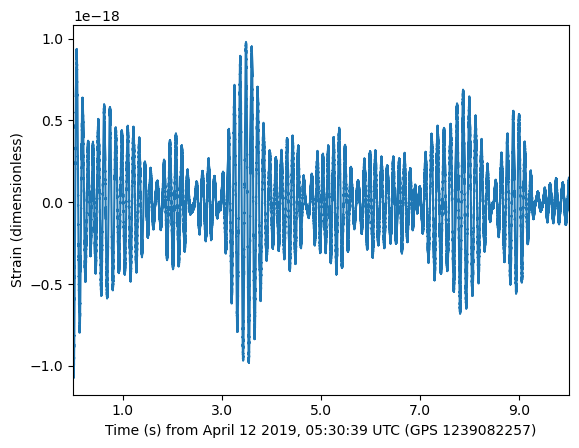

In [7]:
from lal.gpstime import gps_to_str

line = ldata.plot()
figure = line[0].figure
axis = figure.gca()
ticks = axis.get_xticks()
axis.set_xticks(ticks, labels=(ticks - start))
axis.set_xlim(start, stop)
axis.set_xlabel("Time (s) from {0} (GPS {1})".format(gps_to_str(start), start))
axis.set_ylabel("Strain (dimensionless)")

PyCBC contains an interface to the [GWOSC catalog](https://gwosc.org/eventapi/), so you can easily access the data and parameters of the published gravitational-wave signals.
For instance to download strain data you can use the [strain](https://pycbc.org/pycbc/latest/html/pycbc.catalog.html#pycbc.catalog.Merger.strain) method of the [Merger](https://pycbc.org/pycbc/latest/html/pycbc.catalog.html#pycbc.catalog.Merger) class.
This will download the 32s segments around the event.

Text(0, 0.5, 'Strain (dimensionless)')

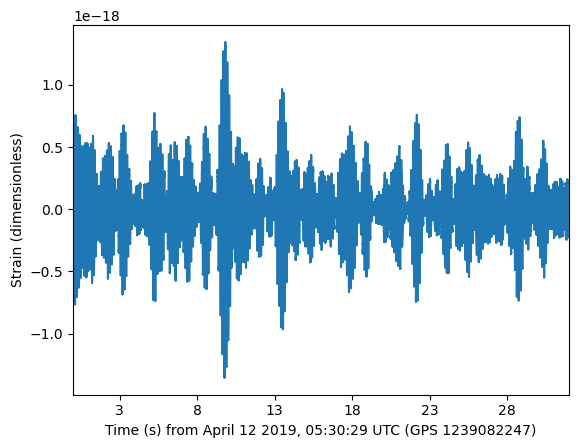

In [8]:
from pycbc.catalog import Merger

GW190412 = Merger('GW190412')
segment = GW190412.strain('L1')
line = segment.plot()
figure = line[0].figure
axis = figure.gca()
ticks = axis.get_xticks()
axis.set_xticks(ticks, labels=(ticks - segment.start_time))
axis.set_xlim(segment.start_time.gpsSeconds, segment.end_time.gpsSeconds)
axis.set_xlabel("Time (s) from {0} (GPS {1})".format(gps_to_str(segment.start_time), segment.start_time))
axis.set_ylabel("Strain (dimensionless)")

# Challenges:

## Quiz Question 1:

Looking at the LIGO-Livingston data in the time domain, the peak amplitude of the gravitational-wave signal of GW190412  occurs at the center of the figure, that is, at approximately 5 seconds from the start of the segment. This peak is undetectable above the background noise by the eye. Plot the data for the LIGO-Hanford detector around GW190412. Looking at your new LIGO-Handford plot, can your eye identify a signal peak? What about Virgo data?